# Modelo Sklearn - Clasificador de Riesgo de crédito (Regresión logística)

In [1]:
import sys
from pathlib import Path

In [2]:
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

In [3]:
from src.credit_risk.data.loader import load_raw_data
from src.credit_risk.data.preprocessing import preprocess_credit_data
from src.credit_risk.features.engineering import build_features

In [4]:
import logging

logging.basicConfig(level=logging.INFO)

In [5]:
paths_config = PROJECT_ROOT / "configs" / "paths.yaml"
model_config = PROJECT_ROOT / "configs" / "model.yaml"

In [6]:
df = load_raw_data(paths_config)
df = preprocess_credit_data(df, model_config)
df = build_features(df)

df.head()

INFO:src.credit_risk.data.preprocessing:Removed 3 rows with invalid age
INFO:src.credit_risk.utils.decorators:Function 'preprocess_credit_data' executed in 0.3038 seconds
INFO:src.credit_risk.utils.decorators:Function 'build_features' executed in 0.0266 seconds


,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status,target,debt_income_ratio,credit_maturity,employment_years,age_group
0,1.0,22,59000,RENT,123.0,PERSONAL,C,35000.0,16.02,10,1.0,3,DEFAULT,1.0,0.593220,0.136364,10.250000,18-25
1,2.0,21,9600,OWN,5.0,EDUCATION,A,1000.0,11.14,1,1.0,2,NO DEFAULT,0.0,0.104167,0.095238,0.416667,18-25
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,5500.0,12.87,5,0.0,3,DEFAULT,1.0,0.572917,0.120000,0.083333,18-25
3,4.0,23,65500,RENT,4.0,MEDICAL,B,35000.0,15.23,10,0.0,2,DEFAULT,1.0,0.534351,0.086957,0.333333,18-25
4,5.0,24,54400,RENT,8.0,MEDICAL,B,35000.0,14.27,10,1.0,4,DEFAULT,1.0,0.643382,0.166667,0.666667,18-25


# Prueba ahora la parte del modelo

In [7]:
from sklearn.model_selection import train_test_split

from src.credit_risk.models.sklearn_model import SklearnCreditModel

In [8]:
X = df.drop(columns=["Current_loan_status", "target"])
y = df["target"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

sk_model = SklearnCreditModel(
    model_config_path=model_config,
    num_cols=num_cols,
    cat_cols=cat_cols,
)

sk_model.train(X_train, y_train)

y_pred = sk_model.predict(X_test)
y_pred_proba = sk_model.predict_proba(X_test)[:, 1]

print(y_pred[:5])
print(y_pred_proba[:5])

[1. 0. 0. 0. 1.]
[0.99885598 0.01034755 0.22278822 0.01915818 0.99770849]


# Probando las métricas 

In [9]:
from src.credit_risk.evaluation.metrics import summarize_metrics

metrics = summarize_metrics(y_test, y_pred, y_pred_proba)
metrics

{'precision_default': 0.9037162162162162,
 'recall_default': 0.7821637426900585,
 'f1_default': 0.8385579937304075,
 'roc_auc': 0.9668424800591496}

In [10]:
# Probando reproducibilidad

metrics_1 = summarize_metrics(y_test, y_pred, y_pred_proba)

# reinicia kernel y vuelve a correr todo

metrics_2 = summarize_metrics(y_test, y_pred, y_pred_proba)

metrics_1 == metrics_2

True

## Resultado del modelo

In [12]:
from src.credit_risk.evaluation.compare import add_model_notes, build_model_comparison
from src.credit_risk.evaluation.results import ModelMetrics
from dataclasses import asdict

sklearn_results = summarize_metrics(y_test, y_pred, y_pred_proba)

sklearn_metrics_obj = ModelMetrics(
    model_name="Logistic Regression",
    precision_default=sklearn_results["precision_default"],
    recall_default=sklearn_results["recall_default"],
    f1_default=sklearn_results["f1_default"],
    roc_auc=sklearn_results["roc_auc"],
    notes="Modelo base interpretable y estable",
)


results = {
    "Logistic Regression": asdict(sklearn_metrics_obj),
}

comparison_df = build_model_comparison(results)

notes = {"Logistic Regression": sklearn_metrics_obj.notes}

comparison_df = add_model_notes(comparison_df, notes)
comparison_df

,model,model_name,precision_default,recall_default,f1_default,roc_auc,notes
0,Logistic Regression,Logistic Regression,0.903716,0.782164,0.838558,0.966842,Modelo base interpretable y estable


In [19]:
# Guardamos el modelo
sk_model.save("../src/credit_risk/models/sklearn_model.pkl")

In [20]:
# Validamos que si exista el modelo
from pathlib import Path

Path("../src/credit_risk/models/sklearn_model.pkl").exists()

True

## Comparación de Modelos

Con el objetivo de contar con una base clara para comparar distintos enfoques, se construyó una tabla resumen con las métricas principales de cada modelo.

Esta comparación permitirá evaluar no solo el desempeño predictivo, sino también aspectos como estabilidad, interpretabilidad y complejidad de implementación.

En esta primera etapa se incluye el modelo de regresión logística como baseline, que posteriormente será comparado contra el modelo desarrollado en PyTorch.

# Prueba de MLFlow

In [21]:
from pathlib import Path

from src.credit_risk.tracking.mlflow_tracker import (
    log_metrics,
    log_params,
    log_sklearn_model,
    set_mlflow_experiment,
    set_tracking_uri,
    start_run,
)

PROJECT_ROOT = Path.cwd().resolve().parent
set_tracking_uri(PROJECT_ROOT / "mlruns")
set_mlflow_experiment("credit-risk-scoring")

with start_run(run_name="logistic_regression_baseline"):
    log_params(
        {
            "model_type": "logistic_regression",
            "test_size": 0.2,
            "random_state": 42,
            "solver": "lbfgs",
            "max_iter": 1000,
        }
    )

    log_metrics(sklearn_results)
    log_sklearn_model(sk_model.pipeline, model_name="sklearn_model")

c:\ITAM\Mod I - python_avanzado\credit-risk-scoring\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/11 16:16:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/11 16:16:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be ad

Evidencia 

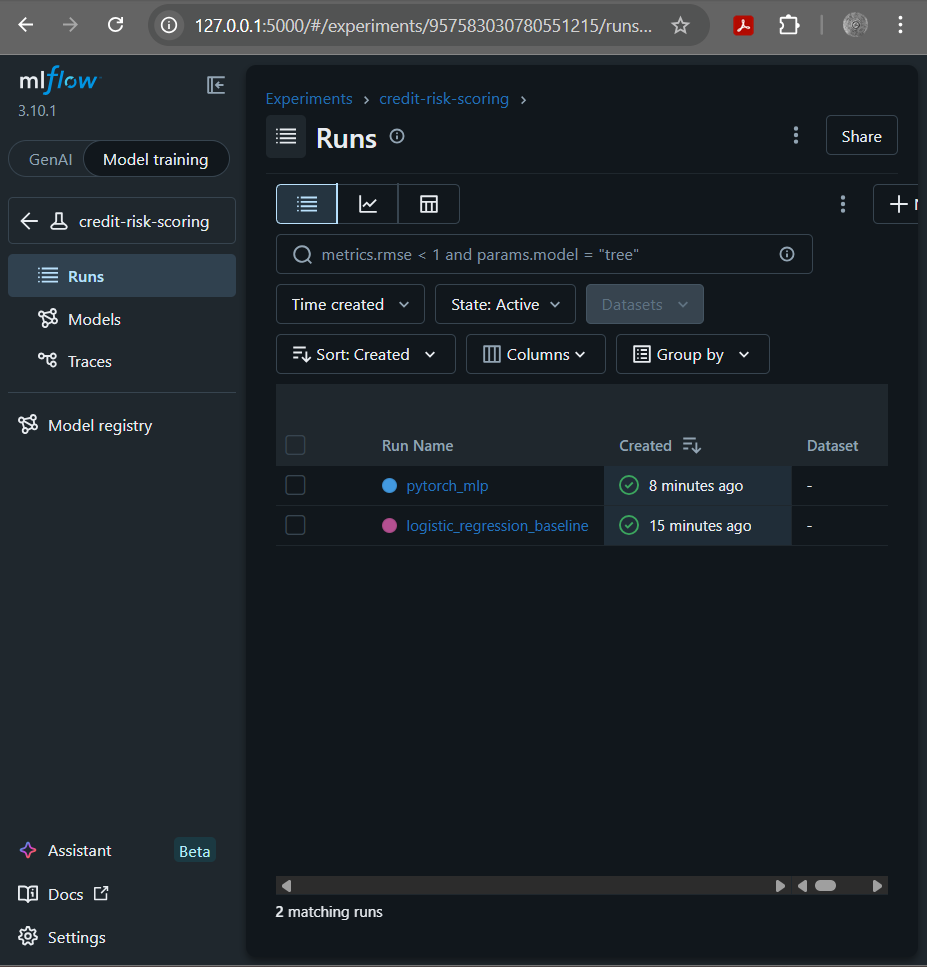